# Analysis of a Counter-Flow Liquid Cooling Heat Exchanger

**1. Problem Statement and Goal**

A Cooling Distribution Unit (CDU) in a liquid-cooled data center uses a counter-flow heat exchanger to transfer thermal energy from a warm server loop (hot fluid) to a facility chilled water loop (cold fluid). 

**Given Parameters:**
* Warm server loop water inlet temperature: $T_{h,\text{in}} = 45\text{ °C}$
* Warm server loop mass flow rate: $\dot{m}_h = 1.2\text{ kg/s}$
* Facility water inlet temperature: $T_{c,\text{in}} = 20\text{ °C}$
* Facility water mass flow rate: $\dot{m}_c = 1.0\text{ kg/s}$
* Overall heat transfer coefficient: $U = 1500\text{ W/(m}^2\cdot\text{K)}$
* Heat exchanger surface area: $A = 4.0\text{ m}^2$

**Goal:**
Determine the heat exchanger effectiveness ($\varepsilon$), total heat transfer rate ($q$), and outlet temperatures for both fluid streams ($T_{h,\text{out}}$ and $T_{c,\text{out}}$) using the $\varepsilon$-$\text{NTU}$ method.

### 2. Schematic
```
T_h,in (45 °C) ----> [ Hot Fluid Stream: Server Loop ] ----> T_h,out
                           =================================
                           =================================
T_c,out <----------- [ Cold Fluid Stream: Facility   ] <---- T_c,in (20 °C)
```

### 3. Assumptions

* Steady-state operation ($\dot{Q}_{\text{accumulation}} = 0$).
* Outer surfaces of the heat exchanger are perfectly insulated ($\dot{Q}_{\text{ambient}} = 0$).
* Fluid physical properties remain constant throughout the heat exchanger.
* Single-phase flow with zero phase change.
* Axial conduction along the heat exchanger walls is negligible.

### 4. Physical Laws

1. **Heat Capacity Rates:**
   $$C_h = \dot{m}_h c_{p,h}, \quad C_c = \dot{m}_c c_{p,c}$$
   $$C_{\min} = \min(C_h, C_c), \quad C_{\max} = \max(C_h, C_c), \quad C_r = \frac{C_{\min}}{C_{\max}}$$

2. **Number of Transfer Units ($\text{NTU}$):**
   $$\text{NTU} = \frac{U A}{C_{\min}}$$

3. **Counter-Flow Effectiveness Relation ($C_r < 1$):**
   $$\varepsilon = \frac{1 - \exp\left[-\text{NTU}(1 - C_r)\right]}{1 - C_r \exp\left[-\text{NTU}(1 - C_r)\right]}$$

4. **Heat Transfer Rates and Outlet Temperatures:**
   $$q_{\max} = C_{\min} (T_{h,\text{in}} - T_{c,\text{in}})$$
   $$q = \varepsilon q_{\max}$$
   $$T_{h,\text{out}} = T_{h,\text{in}} - \frac{q}{C_h}, \quad T_{c,\text{out}} = T_{c,\text{in}} + \frac{q}{C_c}$$

In [2]:
# 5. Properties and Inputs

import math

# Inlet conditions
T_h_in = 45.0  # °C
T_c_in = 20.0  # °C

# Mass flow rates
m_dot_h = 1.2  # kg/s
m_dot_c = 1.0  # kg/s

# Specific heat capacities for liquid water at operating temperatures
cp_h = 4180.0  # J/(kg*K)
cp_c = 4184.0  # J/(kg*K)

# Heat exchanger conductance specifications
U = 1500.0  # W/(m^2*K)
A = 4.0     # m^2

In [3]:
# 6. Calculations

# Step 1: Heat Capacity Rates
C_h = m_dot_h * cp_h  # W/K
C_c = m_dot_c * cp_c  # W/K

C_min = min(C_h, C_c)
C_max = max(C_h, C_c)
C_r = C_min / C_max

# Step 2: Number of Transfer Units (NTU)
NTU = (U * A) / C_min

# Step 3: Effectiveness (Counter-Flow)
if C_r == 1.0:
    epsilon = NTU / (1.0 + NTU)
else:
    exp_term = math.exp(-NTU * (1.0 - C_r))
    epsilon = (1.0 - exp_term) / (1.0 - C_r * exp_term)

# Step 4: Heat Transfer Rates
q_max = C_min * (T_h_in - T_c_in)  # Watts
q = epsilon * q_max                 # Watts

# Step 5: Outlet Temperatures
T_h_out = T_h_in - (q / C_h)
T_c_out = T_c_in + (q / C_c)

# Display formatted results
print(f"Heat Capacity Rate (Hot Stream):  C_h   = {C_h:.2f} W/K")
print(f"Heat Capacity Rate (Cold Stream): C_c   = {C_c:.2f} W/K")
print(f"Capacity Ratio:                   C_r   = {C_r:.4f}")
print(f"Number of Transfer Units:         NTU   = {NTU:.4f}")
print(f"Heat Exchanger Effectiveness:     eps   = {epsilon * 100:.2f}%")
print(f"Maximum Heat Transfer Rate:       q_max = {q_max / 1000:.2f} kW")
print(f"Actual Heat Transfer Rate:        q     = {q / 1000:.2f} kW")
print(f"Hot Stream Outlet Temperature:    T_h,out = {T_h_out:.2f} °C")
print(f"Cold Stream Outlet Temperature:   T_c,out = {T_c_out:.2f} °C")

Heat Capacity Rate (Hot Stream):  C_h   = 5016.00 W/K
Heat Capacity Rate (Cold Stream): C_c   = 4184.00 W/K
Capacity Ratio:                   C_r   = 0.8341
Number of Transfer Units:         NTU   = 1.4340
Heat Exchanger Effectiveness:     eps   = 61.82%
Maximum Heat Transfer Rate:       q_max = 104.60 kW
Actual Heat Transfer Rate:        q     = 64.66 kW
Hot Stream Outlet Temperature:    T_h,out = 32.11 °C
Cold Stream Outlet Temperature:   T_c,out = 35.45 °C


### 7. Conclusion

* The counter-flow heat exchanger achieves an effectiveness of **61.82%**, yielding a total heat rejection rate of **64.66 kW**. In data center liquid cooling applications, an effectiveness between 60% and 80% is standard and usually ideal.
* Trade-off Curve: Achieving $\varepsilon>85$% requires an exponentially larger surface area (A). In a data center environment, larger heat exchangers increase capital cost, occupy precious rack space, and cause higher fluid pressure drops that require more pumping power.
* $\text{NTU} = \frac{UA}{C_{\min}}$ measures the physical transport capacity (conductance $UA$) of the exchanger relative to the heat capacity rate of the limiting fluid stream ($C_{\min}$).
* NTU allows thermal engineers to solve for unknown outlet temperatures directly without relying on iterative guessing, which is necessary when using the Log Mean Temperature Difference (LMTD) method.
* NTU It enables direct comparison of different heat exchanger designs (e.g., plate-frame vs. shell-and-tube) regardless of physical dimensions or working fluid properties.
* On an $\varepsilon$-$\text{NTU}$ plot, effectiveness rises sharply as $\text{NTU}$ increases from $0$ to $1.5$. An $\text{NTU}$ of $1.43$ sits right in this high-gain region.
* Beyond $\text{NTU} \approx 2.0 \text{–} 3.0$, the effectiveness curve flattens significantly. Doubling the surface area from $\text{NTU} = 1.5$ to $3.0$ yields only a minor gain in effectiveness while doubling material costs and pumping losses.
* The server cooling loop leaves the CDU at **32.11 °C**, safely returning to the rack within allowable inlet thresholds.
* The facility chilled water warms up to **35.45 °C** before returning to the central plant loop.

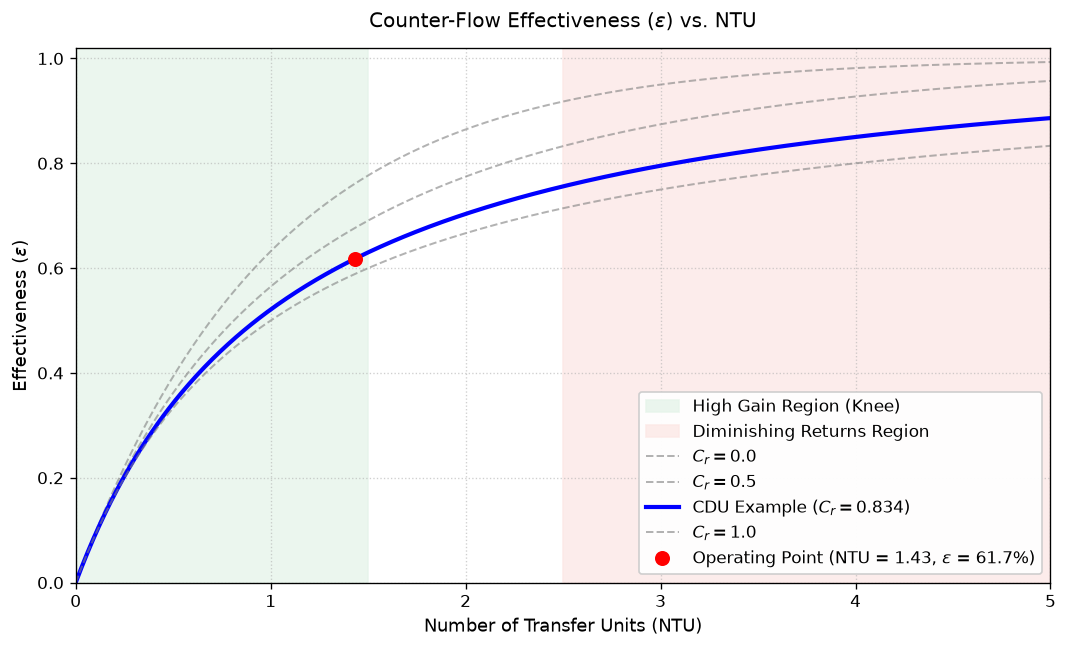

In [8]:
import matplotlib.pyplot as plt
import numpy as np


def counter_flow_effectiveness(ntu, Cr):
    """Calculates counter-flow heat exchanger effectiveness."""
    ntu = np.asarray(ntu)
    if Cr == 1.0:
        return ntu / (1.0 + ntu)
    exp_term = np.exp(-ntu * (1.0 - Cr))
    return (1.0 - exp_term) / (1.0 - Cr * exp_term)


# Parameters from CDU Example
Cr_cdu = 0.834
ntu_op = 1.43
eps_op = counter_flow_effectiveness(ntu_op, Cr_cdu)

# NTU range for plotting
ntu_vals = np.linspace(0, 5, 500)

# Create figure
plt.figure(figsize=(9, 5.5), dpi=120)

# Shading performance regions
plt.axvspan(0, 1.5, color="#e6f4ea", alpha=0.8, label="High Gain Region (Knee)")
plt.axvspan(
    2.5, 5.0, color="#fce8e6", alpha=0.8, label="Diminishing Returns Region"
)

# Plot curves for various capacity ratios (Cr)
for Cr in [0.0, 0.5, Cr_cdu, 1.0]:
    if Cr == Cr_cdu:
        plt.plot(
            ntu_vals,
            counter_flow_effectiveness(ntu_vals, Cr),
            "b-",
            linewidth=2.5,
            label=f"CDU Example ($C_r = {Cr:.3f}$)",
        )
    else:
        plt.plot(
            ntu_vals,
            counter_flow_effectiveness(ntu_vals, Cr),
            "--",
            color="gray",
            alpha=0.6,
            linewidth=1.2,
            label=f"$C_r = {Cr:.1f}$",
        )

# Highlight operating point
plt.plot(
    ntu_op,
    eps_op,
    "ro",
    markersize=8,
    zorder=5,
    label=f"Operating Point (NTU = {ntu_op}, $\epsilon$ = {eps_op:.1%})",
)

# Plot styling
plt.title(
    r"Counter-Flow Effectiveness ($\epsilon$) vs. NTU", fontsize=12, pad=12
)
plt.xlabel("Number of Transfer Units (NTU)", fontsize=11)
plt.ylabel(r"Effectiveness ($\epsilon$)", fontsize=11)
plt.xlim(0, 5)
plt.ylim(0, 1.02)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower right", framealpha=0.95)
plt.tight_layout()

plt.savefig("epsilon_ntu_curve.pdf", format="pdf", bbox_inches="tight")
plt.show()